## End to end Deep Learning Project Using Simple RNN

### Project goal
Build a model that reads a movie review (free text) and predicts whether the sentiment is **Positive** or **Negative**, then use it in a simple web app. The dataset is the Keras **IMDB** set (25,000 training + 25,000 testing reviews, labelled 1 = positive, 0 = negative).

### Project files

| File | Role |
|---|---|
| `embedding.ipynb` | Concept demo: how words become numbers (one-hot indices), why padding is needed, and how an Embedding layer turns IDs into dense vectors. |
| `simplernn.ipynb` (this notebook) | Loads IMDB, preprocesses it, builds, trains and saves the Simple RNN model. |
| `simple_rnn_imdb.h5` | The saved trained model produced by this notebook. |
| `prediction.ipynb` | Loads the saved model and predicts the sentiment of new reviews. |
| `main.py` | Streamlit web app that uses the saved model for live predictions. |
| `requirements.txt` | Python packages needed (TensorFlow 2.15, NumPy, Streamlit, etc.). |

### Workflow (end to end)

```
Raw text  ->  Integer IDs  ->  Fixed length  ->  Embedding  ->  SimpleRNN  ->  Dense (sigmoid)  ->  Positive / Negative
```

1. **Understand the concepts** (`embedding.ipynb`): text must be converted to numbers, sequences must have equal length, and an Embedding layer learns a dense vector for each word.
2. **Load the data** (this notebook): `imdb.load_data(num_words=10000)` returns each review as a list of integers (the 10,000 most frequent words) plus its label.
3. **Explore the data**: inspect a sample review and label, and decode the integers back to words with the reverse word index (remember the ID offset of 3 for the special tokens).
4. **Preprocess**: pad / truncate every review to `max_len = 500` with `pad_sequences`, so the data becomes a `(25000, 500)` matrix.
5. **Build the model**: `Embedding(10000, 128)` -> `SimpleRNN(128, relu)` -> `Dense(1, sigmoid)`.
6. **Compile**: Adam optimizer, `binary_crossentropy` loss, accuracy metric.
7. **Train**: `fit` for up to 10 epochs, batch size 32, 20% validation split, with `EarlyStopping` (watch `val_loss`, patience 5, restore best weights) to avoid overfitting.
8. **Save the model** to `simple_rnn_imdb.h5`.
9. **Predict on new text** (`prediction.ipynb`): load the model, then for a new review lower-case and split it, map words to IDs with the same word index (+3 offset, unknown = 2), pad to 500, run `model.predict` and apply the 0.5 threshold.
10. **Deploy as an app** (`main.py`): a Streamlit page where the user types a review and clicks **Classify**; run it with `streamlit run main.py`.

### Order to run
`embedding.ipynb` (optional, learning) -> `simplernn.ipynb` (train and save) -> `prediction.ipynb` (test) -> `streamlit run main.py` (app).

### Why Simple RNN, and its limits
A Simple RNN reads the review one word at a time and keeps a hidden state as memory, so it can use word order. Its weaknesses are the topic of this section: **vanishing / exploding gradients** and difficulty remembering long-range context (note the huge loss values in some training epochs below). LSTM and GRU layers were designed to fix these problems.

### Step 1 — Import the required libraries

**What this cell does:** imports everything needed for the project.
- `numpy` — numerical arrays.
- `tensorflow` — the deep learning framework.
- `imdb` dataset from `tensorflow.keras.datasets` — 50,000 movie reviews labelled positive/negative.
- `sequence` — utilities for padding sequences to equal length.
- `Sequential` — lets us stack layers one after another.
- `Embedding`, `SimpleRNN`, `Dense` — the three layers of our model:
  - **Embedding** turns word IDs into dense vectors,
  - **SimpleRNN** reads the word vectors one-by-one and keeps a memory of what it has seen,
  - **Dense** produces the final output (the sentiment score).

In [1]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing import sequence
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding,SimpleRNN,Dense

### Step 2 — Load the IMDB dataset

**What this cell does:**
- Sets `max_features = 10000`, the vocabulary size — only the 10,000 most frequent words are kept; rarer words are replaced by a special "unknown" ID.
- Calls `imdb.load_data(num_words=max_features)`, which downloads (first run only) and returns the data already split into **training** and **testing** sets: `(X_train, y_train), (X_test, y_test)`.
- Prints the shapes of the arrays.

**About the data:** each review is already converted to a list of integers (each integer = one word). Labels are `1` (positive) or `0` (negative). There are 25,000 training and 25,000 testing reviews.

**Note:** the second `print` statement uses `X_train.shape` for the *testing* data, so it shows the training shape by mistake. It should read `X_test.shape`; the numbers happen to be the same (25,000) here.

In [2]:
## Load the imdb dataset

max_features=10000 ##vocabulary size
(X_train,y_train),(X_test,y_test)=imdb.load_data(num_words=max_features)

# Print the shape of the data
print(f'Training data shape: {X_train.shape}, Training labels shape: {y_train.shape}')
print(f'Testing data shape: {X_train.shape}, Testing labels shape: {y_test.shape}')

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training data shape: (25000,), Training labels shape: (25000,)
Testing data shape: (25000,), Testing labels shape: (25000,)


### Step 3 — Peek at the first training review and label

**What this cell does:** shows `X_train[0]` (the first review as a list of integers) and `y_train[0]` (its label).

**Why it is needed:** to verify that the data is loaded and to understand its format. Each number is a word's rank in the frequency list (1 = start token, 2 = unknown word, 4 = `the`, etc.). Reviews have different lengths — which is why padding is needed later.

In [4]:
X_train[0]

[1,
 14,
 22,
 16,
 43,
 530,
 973,
 1622,
 1385,
 65,
 458,
 4468,
 66,
 3941,
 4,
 173,
 36,
 256,
 5,
 25,
 100,
 43,
 838,
 112,
 50,
 670,
 2,
 9,
 35,
 480,
 284,
 5,
 150,
 4,
 172,
 112,
 167,
 2,
 336,
 385,
 39,
 4,
 172,
 4536,
 1111,
 17,
 546,
 38,
 13,
 447,
 4,
 192,
 50,
 16,
 6,
 147,
 2025,
 19,
 14,
 22,
 4,
 1920,
 4613,
 469,
 4,
 22,
 71,
 87,
 12,
 16,
 43,
 530,
 38,
 76,
 15,
 13,
 1247,
 4,
 22,
 17,
 515,
 17,
 12,
 16,
 626,
 18,
 2,
 5,
 62,
 386,
 12,
 8,
 316,
 8,
 106,
 5,
 4,
 2223,
 5244,
 16,
 480,
 66,
 3785,
 33,
 4,
 130,
 12,
 16,
 38,
 619,
 5,
 25,
 124,
 51,
 36,
 135,
 48,
 25,
 1415,
 33,
 6,
 22,
 12,
 215,
 28,
 77,
 52,
 5,
 14,
 407,
 16,
 82,
 2,
 8,
 4,
 107,
 117,
 5952,
 15,
 256,
 4,
 2,
 7,
 3766,
 5,
 723,
 36,
 71,
 43,
 530,
 476,
 26,
 400,
 317,
 46,
 7,
 4,
 2,
 1029,
 13,
 104,
 88,
 4,
 381,
 15,
 297,
 98,
 32,
 2071,
 56,
 26,
 141,
 6,
 194,
 7486,
 18,
 4,
 226,
 22,
 21,
 134,
 476,
 26,
 480,
 5,
 144,
 30,
 5535,
 18,

In [5]:
y_train[0]

np.int64(1)

### Step 4 — Inspect a sample review and its label

**What this cell does:** stores the first review and label in `sample_review` and `sample_label`, then prints them with readable messages.

**Why it is needed:** this is the same inspection as the previous cell but with clear labels, so you can see that the review is just a sequence of integers and the label is `1` (positive) or `0` (negative). These variables are reused in the decoding step below.

In [6]:
## Inspect a sample review and its label
sample_review=X_train[0]
sample_label=y_train[0]

print(f"Sample review (as integers):{sample_review}")
print(f'Sample label: {sample_label}')


Sample review (as integers):[1, 14, 22, 16, 43, 530, 973, 1622, 1385, 65, 458, 4468, 66, 3941, 4, 173, 36, 256, 5, 25, 100, 43, 838, 112, 50, 670, 2, 9, 35, 480, 284, 5, 150, 4, 172, 112, 167, 2, 336, 385, 39, 4, 172, 4536, 1111, 17, 546, 38, 13, 447, 4, 192, 50, 16, 6, 147, 2025, 19, 14, 22, 4, 1920, 4613, 469, 4, 22, 71, 87, 12, 16, 43, 530, 38, 76, 15, 13, 1247, 4, 22, 17, 515, 17, 12, 16, 626, 18, 2, 5, 62, 386, 12, 8, 316, 8, 106, 5, 4, 2223, 5244, 16, 480, 66, 3785, 33, 4, 130, 12, 16, 38, 619, 5, 25, 124, 51, 36, 135, 48, 25, 1415, 33, 6, 22, 12, 215, 28, 77, 52, 5, 14, 407, 16, 82, 2, 8, 4, 107, 117, 5952, 15, 256, 4, 2, 7, 3766, 5, 723, 36, 71, 43, 530, 476, 26, 400, 317, 46, 7, 4, 2, 1029, 13, 104, 88, 4, 381, 15, 297, 98, 32, 2071, 56, 26, 141, 6, 194, 7486, 18, 4, 226, 22, 21, 134, 476, 26, 480, 5, 144, 30, 5535, 18, 51, 36, 28, 224, 92, 25, 104, 4, 226, 65, 16, 38, 1334, 88, 12, 16, 283, 5, 16, 4472, 113, 103, 32, 15, 16, 5345, 19, 178, 32]
Sample label: 1


### Step 5 — Build a reverse dictionary (ID → word)

**What this cell does:**
1. `imdb.get_word_index()` returns a dictionary mapping each **word → its integer ID** (the whole dataset vocabulary, ~88,000 words).
2. `reverse_word_index = {value: key ...}` flips it into **ID → word**, so we can translate numbers back into text.

**Why it is needed:** machines work with integers but humans want to read the review. This reverse mapping lets us decode a review and, later in the prediction notebook, helps us understand the model's input.

In [7]:
### MApping of words index bacl to words(for understanding)
word_index=imdb.get_word_index()
#word_index
reverse_word_index = {value: key for key, value in word_index.items()}
reverse_word_index

1641221/1641221 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


{34701: 'fawn',
 52006: 'tsukino',
 52007: 'nunnery',
 16816: 'sonja',
 63951: 'vani',
 1408: 'woods',
 16115: 'spiders',
 2345: 'hanging',
 2289: 'woody',
 52008: 'trawling',
 52009: "hold's",
 11307: 'comically',
 40830: 'localized',
 30568: 'disobeying',
 52010: "'royale",
 40831: "harpo's",
 52011: 'canet',
 19313: 'aileen',
 52012: 'acurately',
 52013: "diplomat's",
 25242: 'rickman',
 6746: 'arranged',
 52014: 'rumbustious',
 52015: 'familiarness',
 52016: "spider'",
 68804: 'hahahah',
 52017: "wood'",
 40833: 'transvestism',
 34702: "hangin'",
 2338: 'bringing',
 40834: 'seamier',
 34703: 'wooded',
 52018: 'bravora',
 16817: 'grueling',
 1636: 'wooden',
 16818: 'wednesday',
 52019: "'prix",
 34704: 'altagracia',
 52020: 'circuitry',
 11585: 'crotch',
 57766: 'busybody',
 52021: "tart'n'tangy",
 14129: 'burgade',
 52023: 'thrace',
 11038: "tom's",
 52025: 'snuggles',
 29114: 'francesco',
 52027: 'complainers',
 52125: 'templarios',
 40835: '272',
 52028: '273',
 52130: 'zaniacs',

In [17]:
reverse_word_index[3]

'a'

### Step 6 — Decode the sample review back to English

**The code**

```python
decoded_review = ' '.join([reverse_word_index.get(i - 3, '?') for i in sample_review])
decoded_review
```

**Goal:** `sample_review` is a list of integers (e.g. `[1, 14, 22, 16, 43, ...]`). This line translates every integer back into its word and joins them into one readable sentence, so we can see what the model is really reading.

**Read it from the inside out**

| Part | Meaning |
|---|---|
| `for i in sample_review` | Loop over every integer `i` (word ID) in the review. |
| `i - 3` | Undo the offset Keras added to the IDs (explained below). |
| `reverse_word_index.get(i - 3, '?')` | Look up the word for that ID in the dictionary. If the ID is missing, return `'?'` instead of raising an error. |
| `[ ... for i in ... ]` | A list comprehension that collects all the words into a list, e.g. `['?', 'this', 'film', 'was', ...]`. |
| `' '.join(list)` | Joins the list into one string, with a single space between words. |

**Same thing as a normal loop**

```python
words = []
for i in sample_review:
    word = reverse_word_index.get(i - 3, '?')
    words.append(word)
decoded_review = ' '.join(words)
```

**Why `i - 3`? (the offset)**
- `imdb.get_word_index()` numbers words from `1` (`the` = 1, `and` = 2, ...).
- When `imdb.load_data()` builds the review arrays it **shifts every real word ID up by 3** and reserves the first three IDs for special tokens:

| ID | Token |
|---|---|
| `0` | padding |
| `1` | start of sequence |
| `2` | unknown / out-of-vocabulary word (any word outside the top 10,000) |

- So the word `the` appears in the review as `4` (1 + 3). Subtracting 3 gives back the original dictionary key: `4 - 3 = 1` -> `'the'`.

**Why `.get(..., '?')` instead of `[...]`**
- For the special IDs `0`, `1` and `2` (and ID `3`) the subtracted values are `-3`, `-2`, `-1` and `0`, which do not exist in `reverse_word_index`.
- `dict[key]` would crash with a `KeyError`; `dict.get(key, '?')` returns the default `'?'`.
- That is why the decoded text begins with `?`: the first number of every review is `1` (start token).

**Worked example (first review)**

| ID `i` | `i - 3` | Word |
|---|---|---|
| 1 | -2 | `?` (start token) |
| 14 | 11 | `this` |
| 22 | 19 | `film` |
| 16 | 13 | `was` |
| 43 | 40 | `just` |
| 530 | 527 | `brilliant` |

**Output:** a single string such as *"? this film was just brilliant casting location scenery story direction everyone's really suited the part they played ..."*. Every `?` in it is a special or unknown token (start marker, or a rare word that was replaced by `2`).

**Notes**
- This decoding is only for **understanding** the data; the model never uses the text, only the integers.
- It works only on the unpadded review (`sample_review`). On a padded review the many `0`s at the front would all appear as `?`.
- The last line, `decoded_review`, simply displays the string in the notebook.

In [18]:
decoded_review = ' '.join([reverse_word_index.get(i - 3, '?') for i in sample_review])
decoded_review

"? this film was just brilliant casting location scenery story direction everyone's really suited the part they played and you could just imagine being there robert ? is an amazing actor and now the same being director ? father came from the same scottish island as myself so i loved the fact there was a real connection with this film the witty remarks throughout the film were great it was just brilliant so much that i bought the film as soon as it was released for ? and would recommend it to everyone to watch and the fly fishing was amazing really cried at the end it was so sad and you know what they say if you cry at a film it must have been good and this definitely was also ? to the two little boy's that played the ? of norman and paul they were just brilliant children are often left out of the ? list i think because the stars that play them all grown up are such a big profile for the whole film but these children are amazing and should be praised for what they have done don't you th

### Step 7 — Pad all reviews to the same length

**What this cell does:**
- Sets `max_len = 500` (every review will be exactly 500 words/IDs long).
- Applies `sequence.pad_sequences(...)` to both `X_train` and `X_test`.

**How it works:**
- Reviews shorter than 500 are padded with `0`s at the **start** (default `padding='pre'`).
- Reviews longer than 500 are truncated (extra words at the start are cut by default).

**Why it is needed:** the network needs fixed-size input matrices. After this step `X_train` has shape `(25000, 500)` and `X_test` has shape `(25000, 500)`.

In [19]:
from tensorflow.keras.preprocessing import sequence

max_len=500

X_train=sequence.pad_sequences(X_train,maxlen=max_len)
X_test = sequence.pad_sequences(X_test, maxlen=max_len)
X_train

array([[   0,    0,    0, ...,   19,  178,   32],
       [   0,    0,    0, ...,   16,  145,   95],
       [   0,    0,    0, ...,    7,  129,  113],
       ...,
       [   0,    0,    0, ...,    4, 3586,    2],
       [   0,    0,    0, ...,   12,    9,   23],
       [   0,    0,    0, ...,  204,  131,    9]], dtype=int32)

In [20]:
import pandas as pd
s =pd.DataFrame(X_train)
s

,0,1,2,3,4,5,6,7,8,9,...,490,491,492,493,494,495,496,497,498,499
0,0,0,0,0,0,0,0,0,0,0,...,4472,113,103,32,15,16,5345,19,178,32
1,0,0,0,0,0,0,0,0,0,0,...,52,154,462,33,89,78,285,16,145,95
2,0,0,0,0,0,0,0,0,0,0,...,106,607,624,35,534,6,227,7,129,113
3,687,23,4,2,7339,6,3693,42,38,39,...,26,49,7008,15,566,30,579,21,64,2574
4,0,0,0,0,0,0,0,0,0,0,...,19,14,5,7224,6,226,251,7,61,113
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24995,0,0,0,0,0,0,0,0,0,0,...,5412,198,646,196,17,25,2537,12,17,1219
24996,0,0,0,0,0,0,0,0,0,0,...,7562,13,482,15,5902,2568,4,359,18,2
24997,0,0,0,0,0,0,0,0,0,0,...,1006,541,9303,7,4,59,2,4,3586,2
24998,0,0,0,0,0,0,0,0,0,0,...,5,2,12,38,84,80,124,12,9,23


### Step 8 — Look at a padded review

**What this cell does:** prints `X_train[0]` after padding.

**What to observe:** a long run of `0`s at the beginning (the padding) followed by the real word IDs at the end. Padding at the front is helpful for RNNs since the most recent words are right next to the final output, reducing how much the network must "remember".

In [21]:
X_train[0]

array([   0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,   

In [22]:
import pandas as pd
s =pd.DataFrame(X_train[0])
s

,0
0,0
1,0
2,0
3,0
4,0
...,...
495,16
496,5345
497,19
498,178


### Step 9 — Define the Simple RNN model

**What this cell does:** builds a `Sequential` model with three layers:

1. **`Embedding(max_features, 128, input_length=max_len)`** — turns each of the 500 word IDs into a 128-number vector. The table has `10,000 × 128` entries and is learned during training.
2. **`SimpleRNN(128, activation='relu')`** — reads the 500 vectors one at a time. It has 128 hidden units that carry a "memory" from word to word and returns only its **final** state (a 128-number summary of the whole review). `relu` is used as the activation instead of the default `tanh`.
3. **`Dense(1, activation='sigmoid')`** — a single neuron whose sigmoid output is a probability between 0 and 1 (close to 1 = positive review, close to 0 = negative).

**Concept:** because a SimpleRNN multiplies by the same weights at every time step, long sequences can suffer from vanishing/exploding gradients — the core "problem with RNN" this section is about (see the large loss values in the training log below).

### Step 9 — Define the Simple RNN model

**The code**

```python
model=Sequential()
model.add(Embedding(max_features,128,input_length=max_len)) ## Embedding Layers
model.add(SimpleRNN(128,activation='relu'))
model.add(Dense(1,activation="sigmoid"))
```

**Big picture:** the model is a stack of three layers. Data flows through them in order:

```
(batch, 500)  ->  Embedding  ->  (batch, 500, 128)  ->  SimpleRNN  ->  (batch, 128)  ->  Dense  ->  (batch, 1)
 word IDs          word vectors                          review summary                    probability
```

---

#### Line 1 — `model = Sequential()`
Creates an empty model that stacks layers in a straight line: the output of one layer is the input of the next. `model.add(...)` appends each layer.

---

#### Line 2 — `Embedding(max_features, 128, input_length=max_len)`

| Argument | Value | Meaning |
|---|---|---|
| `max_features` | 10,000 | Vocabulary size: the layer holds one vector for each of the 10,000 possible word IDs. |
| `128` | 128 | Embedding dimension: each word becomes a vector of 128 numbers. |
| `input_length=max_len` | 500 | Every review has exactly 500 word IDs (we padded to this length). |

- It is a **trainable lookup table** of shape `(10000, 128)`. Word ID `n` simply picks row `n`.
- **Input shape:** `(batch, 500)`, the padded integer reviews. **Output shape:** `(batch, 500, 128)`.
- **Parameters:** `10,000 x 128 = 1,280,000`.
- Instead of a meaningless ID, each word now has 128 learnable numbers. During training, words used in similar ways (e.g. *great* / *excellent*) move to similar vectors.
- `input_length` is only needed so the model knows its input shape. Newer Keras versions deprecate it, but it works with TensorFlow 2.15.

---

#### Line 3 — `SimpleRNN(128, activation='relu')`

| Argument | Meaning |
|---|---|
| `128` | Number of hidden units: the size of the memory (hidden state) the layer carries from word to word. |
| `activation='relu'` | Function applied to the layer's output at each step. The default is `tanh`; `relu` = `max(0, x)`. |

**How it works:** the layer reads the 500 word vectors **one at a time**, in order. At each time step `t` it computes:

```
h_t = relu( x_t . W_x  +  h_(t-1) . W_h  +  b )
```

- `x_t` is the current word's 128-number vector,
- `h_(t-1)` is the memory (hidden state) from the previous word,
- `h_t` is the updated memory.

By default (`return_sequences=False`) it returns **only the final state `h_500`**, a single 128-number summary of the whole review. So the output shape is `(batch, 128)`.

**Parameters (32,896):**

| Part | Shape | Count | Role |
|---|---|---|---|
| `W_x` (input -> hidden) | 128 x 128 | 16,384 | Maps the word's 128-number embedding to the 128 hidden units. |
| `W_h` (hidden -> hidden) | 128 x 128 | 16,384 | The recurrence: every unit receives the previous output of all 128 units, so the units "communicate" and form the memory. |
| `b` (bias) | 128 | 128 | One bias per unit. |

General formula: `units x (input_dim + units + 1) = 128 x (128 + 128 + 1) = 32,896`.

Both matrices happen to be 128 x 128 only because the embedding size and the number of units are both 128. The same `W_x`, `W_h` and `b` are reused at **all 500 time steps**, so the parameter count does not depend on the review length.

**Weakness:** because the same `W_h` is multiplied again and again over 500 steps, gradients can **vanish** (memory of early words is lost) or **explode** (the huge loss values seen in training). This is the main problem of simple RNNs that LSTM/GRU solve.

---

#### Line 4 — `Dense(1, activation="sigmoid")`
- A single output neuron connected to all 128 values of the RNN summary.
- **Parameters:** `128 weights + 1 bias = 129`.
- **Sigmoid** `1 / (1 + e^-x)` squashes any number into the range 0 to 1, so the output is read as the **probability that the review is positive**.
- Output shape: `(batch, 1)`. In the prediction step, a value above `0.5` means **Positive**, otherwise **Negative**.
- Sigmoid with one neuron is the standard choice for **binary** (two-class) problems, and pairs with the `binary_crossentropy` loss used in compile.

---

#### Total parameters

| Layer | Output shape | Parameters |
|---|---|---|
| Embedding | `(None, 500, 128)` | 1,280,000 |
| SimpleRNN | `(None, 128)` | 32,896 |
| Dense | `(None, 1)` | 129 |
| **Total** | | **1,313,025** |

Almost all parameters (about 97%) are in the embedding table, not in the RNN.

In [23]:
## Train Simple RNN
model=Sequential()
model.add(Embedding(max_features,128,input_length=max_len)) ## Embedding Layers
model.add(SimpleRNN(128,activation='relu'))
model.add(Dense(1,activation="sigmoid"))

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


### Step 10 — View the model summary

**What this cell does:** prints each layer, its output shape and the number of parameters.

**How to read it:**
- `embedding` → output `(None, 500, 128)`, **1,280,000** parameters (`10,000 × 128`).
- `simple_rnn` → output `(None, 128)`, **32,896** parameters (`128×128` input weights + `128×128` recurrent weights + `128` biases).
- `dense` → output `(None, 1)`, **129** parameters (`128` weights + `1` bias).
- Total: **1,313,025** trainable parameters (~5 MB).

In [24]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

### Step 11 — Compile the model

**What this cell does:** configures how the model will learn:
- `optimizer='adam'` — an adaptive gradient-descent algorithm that adjusts the learning rate automatically.
- `loss='binary_crossentropy'` — the standard loss for two-class (positive/negative) problems with a sigmoid output.
- `metrics=['accuracy']` — reports the percentage of correct predictions during training.

In [25]:
model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])

### Step 12 — Create an Early Stopping callback

**What this cell does:** creates an `EarlyStopping` object that watches the validation loss.
- `monitor='val_loss'` — the metric to watch (loss on data not used for training).
- `patience=5` — stop training if `val_loss` has not improved for 5 epochs in a row.
- `restore_best_weights=True` — when stopping, go back to the weights from the epoch with the best `val_loss`.

**Why it is needed:** it prevents **overfitting** (the model memorising the training reviews) and saves training time. The output line only shows the object's memory address, which is normal.

In [26]:
## Create an instance of EarlyStoppping Callback
from tensorflow.keras.callbacks import EarlyStopping
earlystopping=EarlyStopping(monitor='val_loss',patience=5,restore_best_weights=True)
earlystopping

### Step 13 — Train the model

**What this cell does:** calls `model.fit(...)` with:
- `X_train, y_train` — the padded reviews and their labels,
- `epochs=10` — at most 10 full passes through the training data,
- `batch_size=32` — weights are updated after every 32 reviews (625 steps per epoch),
- `validation_split=0.2` — 20% of the training data (5,000 reviews) is held back to check performance on unseen data,
- `callbacks=[earlystopping]` — enables early stopping.

The returned `history` object stores the loss and accuracy of every epoch, which can be used to plot learning curves.

**Reading the log:** in epochs 1, 2, 4 and 5 the training loss is huge (9197, 21616, 16, 52) — a sign of **exploding gradients**, a classic problem of simple RNNs with ReLU. The model then stabilises and in the end reaches about **94% training accuracy** and about **81% validation accuracy** (epoch 10). The gap between the two shows some overfitting.

In [27]:
## Train the model with early sstopping
history=model.fit(
    X_train,y_train,epochs=10,batch_size=32,
    validation_split=0.2,
    callbacks=[earlystopping]
)

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 146s 231ms/step - accuracy: 0.5912 - loss: 3175751.7500 - val_accuracy: 0.6452 - val_loss: 0.6151
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 141s 226ms/step - accuracy: 0.7136 - loss: 3.5607 - val_accuracy: 0.7012 - val_loss: 0.5605
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 142s 227ms/step - accuracy: 0.7788 - loss: 0.4932 - val_accuracy: 0.7122 - val_loss: 0.5480
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 142s 227ms/step - accuracy: 0.8469 - loss: 0.3761 - val_accuracy: 0.8056 - val_loss: 0.4229
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 141s 225ms/step - accuracy: 0.9055 - loss: 0.2527 - val_accuracy: 0.8202 - val_loss: 0.4261
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 141s 224ms/step - accuracy: 0.9408 - loss: 0.1784 - val_accuracy: 0.8306 - val_loss: 0.4419
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 142s 225ms/step - accuracy: 0.9595 - loss: 0.1320 - val_accuracy: 0.8298 - val_loss: 0.4572
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 142s 227ms/step - accuracy: 0.

### Step 14 — Save the trained model

**What this cell does:** saves the architecture and learned weights to the file `simple_rnn_imdb.h5`.

**Why it is needed:** training takes several minutes. By saving the model we can load it in another notebook (`prediction.ipynb`) or in the Streamlit app (`main.py`) and make predictions instantly without re-training.

**Note:** the warning shown says the `.h5` (HDF5) format is legacy; the recommended newer format is `model.save('simple_rnn_imdb.keras')`. The `.h5` file still works fine.

In [28]:
## Save model file
model.save('simple_rnn_imdb.h5')

Extra knowledge

Word ID: each word in the vocabulary is represented by an integer, e.g. the is 4, film is 22, brilliant is 530.

Vocabulary: you set max_features = 10000, so IDs run from 0 to 9999. That's 10,000 possible IDs, covering padding, start, unknown and the most frequent words.

One row per ID: the table has 10,000 rows, and each row has 128 numbers.

Row (ID)   128 numbers (learned during training)
  0     [ 0.01, -0.03, ..., 0.02 ]    <- padding
  1     [ ...                    ]    <- start token
  2     [ ...                    ]    <- unknown word
  ...
  4     [ 0.12,  0.05, ..., -0.07 ]   <- "the"
  ...
 530    [ -0.40, 0.31, ..., 0.18  ]   <- "brilliant"
  ...
 9999   [ ...                    ]

How it's used

For the review [1, 14, 22, ...] the layer does a lookup, not a calculation:

ID 1 copies row 1.
ID 14 copies row 14.
ID 22 copies row 22.
Each ID is replaced by its row. A review of 500 IDs becomes a 500 × 128 block of numbers.

Why it matters

The rows start random. Training adjusts them, so words used in similar ways end up with similar rows.
The parameter count is rows × columns = 10,000 × 128 = 1,280,000.
Words outside the top 10,000 don't get their own row. They all share ID 2 (unknown).




Yes, the vocabulary size is 10k. max_features = 10000 means the model knows the 10,000 most frequent words in the IMDB reviews.

Inside the 10k: each word has its own row of 128 learned numbers in the embedding table.
Outside the 10k: rarer words don't get their own row. load_data replaces them with ID 2 (unknown), which is why some words show up as ? when you decode a review.
Special IDs: 0 (padding), 1 (start) and 2 (unknown) use up 3 of the 10,000 slots, so about 9,997 slots are left for real words.
Where it appears: in imdb.load_data(num_words=max_features) and as the first argument of Embedding(max_features, 128, ...). The two must match, or IDs would point to rows that don't exist.
Why the number matters:
A larger vocabulary keeps more words but makes the embedding table bigger (the parameters grow by 128 for each extra word).
A smaller one is lighter but turns more words into "unknown".
10,000 is a common compromise for IMDB.
I haven't changed any files.










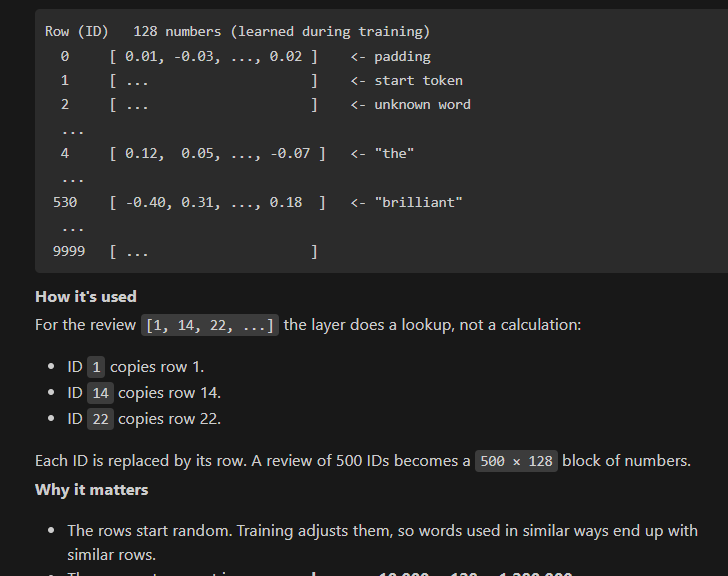

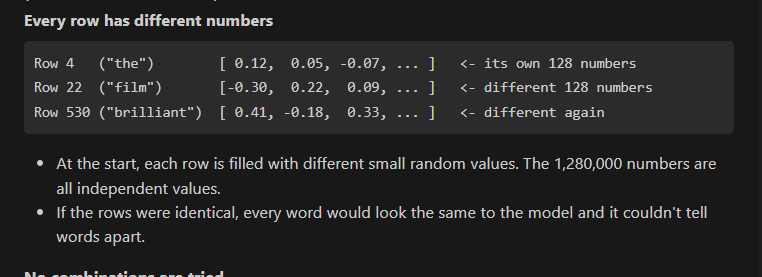

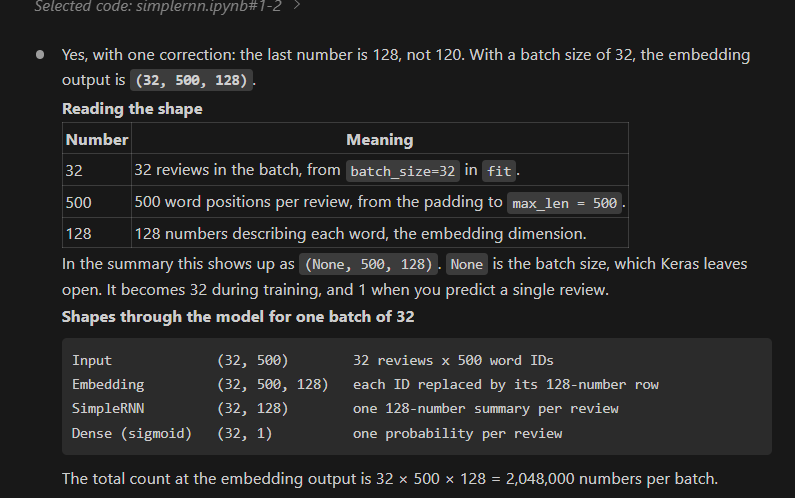

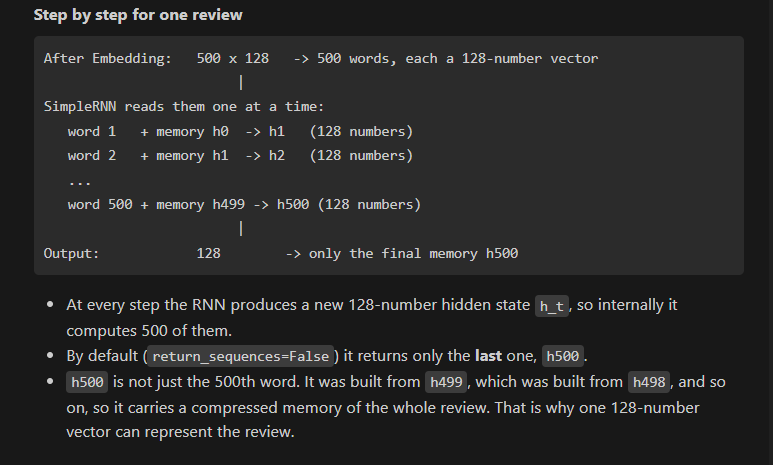

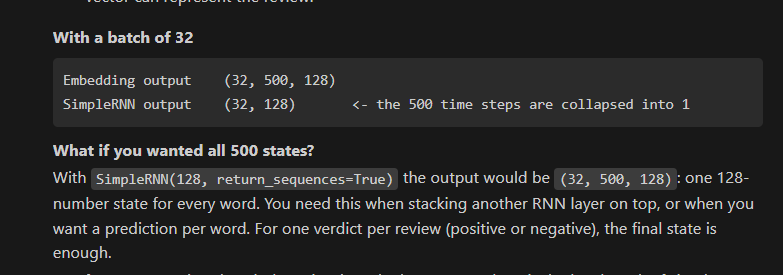